In [1]:
import kagglehub

# Download latest version of the dataset
path = kagglehub.dataset_download("larsen0966/student-performance-data-set")

print("Path to dataset files:", path)

Path to dataset files: /Users/ducnguyen/.cache/kagglehub/datasets/larsen0966/student-performance-data-set/versions/2


In [2]:
import pandas as pd
import os

df = pd.read_csv(os.path.join(path, "student-por.csv"))

print(df.shape)
df.head()

(649, 33)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      649 non-null    str  
 1   sex         649 non-null    str  
 2   age         649 non-null    int64
 3   address     649 non-null    str  
 4   famsize     649 non-null    str  
 5   Pstatus     649 non-null    str  
 6   Medu        649 non-null    int64
 7   Fedu        649 non-null    int64
 8   Mjob        649 non-null    str  
 9   Fjob        649 non-null    str  
 10  reason      649 non-null    str  
 11  guardian    649 non-null    str  
 12  traveltime  649 non-null    int64
 13  studytime   649 non-null    int64
 14  failures    649 non-null    int64
 15  schoolsup   649 non-null    str  
 16  famsup      649 non-null    str  
 17  paid        649 non-null    str  
 18  activities  649 non-null    str  
 19  nursery     649 non-null    str  
 20  higher      649 non-null    str  
 21  inte

The objective is to predict students' performance based on their study hours, attendance, past grades, and participation in extracurricular activities. 
The Kaggle dataset has similar features: studytime, absences, activities, G1, and G2.
The grades are from 0 to 20, so the 80% mark is around 16.

In [4]:
df.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000
mean,16.744222,2.514638,2.306626,1.568567,1.930663,0.221880,3.930663,3.180277,3.184900,1.502311,2.280431,3.536210,3.659476,11.399076,11.570108,11.906009
std,1.218138,1.134552,1.099931,0.748660,0.829510,0.593235,0.955717,1.051093,1.175766,0.924834,1.284380,1.446259,4.640759,2.745265,2.913639,3.230656
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,16.000000,2.000000,1.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,2.000000,0.000000,10.000000,10.000000,10.000000
50%,17.000000,2.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,2.000000,11.000000,11.000000,12.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,6.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,32.000000,19.000000,19.000000,19.000000


In [5]:
print("studytime values:")
print(df['studytime'].value_counts())
print("\nactivities values:")
print(df['activities'].value_counts())
print("\nG3 (final grade) summary:")
print(df['G3'].describe())

studytime values:
studytime
2    305
1    212
3     97
4     35
Name: count, dtype: int64

activities values:
activities
no     334
yes    315
Name: count, dtype: int64

G3 (final grade) summary:
count    649.000000
mean      11.906009
std        3.230656
min        0.000000
25%       10.000000
50%       12.000000
75%       14.000000
max       19.000000
Name: G3, dtype: float64


school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64
count    649.000000
mean       3.659476
std        4.640759
min        0.000000
25%        0.000000
50%        2.000000
75%        6.000000
max       32.000000
Name: absences, dtype: float64


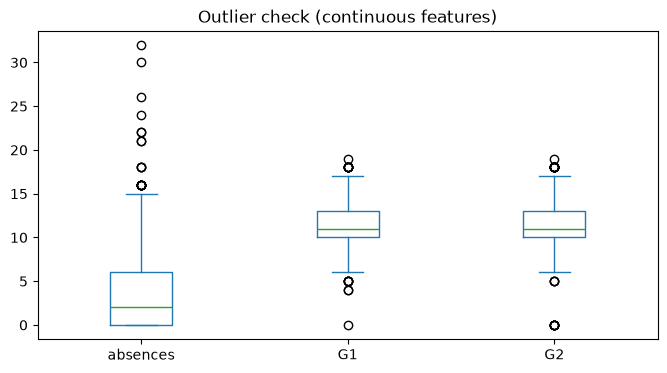


Total missing values: 0


In [6]:
print(df.isnull().sum())

# Outlier check on continuous features
import matplotlib.pyplot as plt
print(df['absences'].describe())
df[['absences', 'G1', 'G2']].plot(kind='box', figsize=(8, 4),
                                  title='Outlier check (continuous features)')
plt.show()

print("\nTotal missing values:", df.isnull().sum().sum())

No data is missing. Absences have some outliers (a long tail).

In [7]:
Q1, Q3 = df['absences'].quantile([0.25, 0.75])
IQR = Q3 - Q1
upper = Q3 + 1.5 * IQR
n_capped = int((df['absences'] > upper).sum())

df['absences'] = df['absences'].clip(upper=upper)

print(f"Upper fence for absences: {upper:.1f}")
print(f"Capped {n_capped} outlier rows. New max: {df['absences'].max():.1f}")

Upper fence for absences: 15.0
Capped 21 outlier rows. New max: 15.0


Switching the cap to 15 (the IQR upper fence), which affected 21 rows.

In [8]:
df['performance'] = (df['G3'] >= 16).astype(int)
df['performance'].value_counts()

performance
0    567
1     82
Name: count, dtype: int64

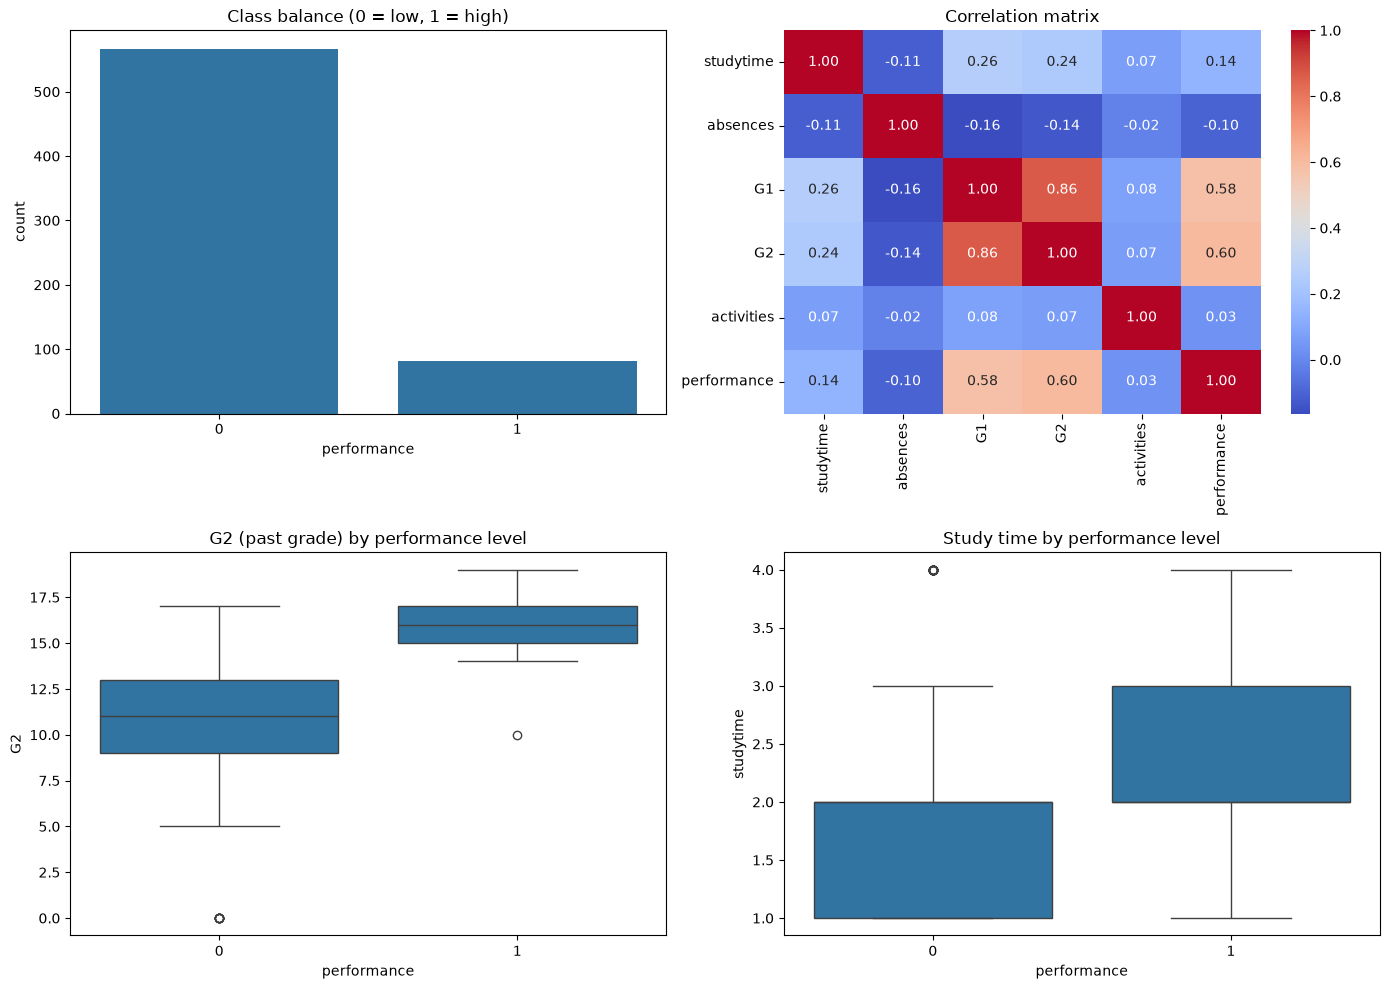

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

eda = df.copy()
eda['activities'] = eda['activities'].map({'yes': 1, 'no': 0})
features = ['studytime', 'absences', 'G1', 'G2', 'activities', 'performance']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.countplot(x='performance', data=eda, ax=axes[0, 0])
axes[0, 0].set_title('Class balance (0 = low, 1 = high)')

sns.heatmap(eda[features].corr(), annot=True, cmap='coolwarm', fmt='.2f', ax=axes[0, 1])
axes[0, 1].set_title('Correlation matrix')

sns.boxplot(x='performance', y='G2', data=eda, ax=axes[1, 0])
axes[1, 0].set_title('G2 (past grade) by performance level')

sns.boxplot(x='performance', y='studytime', data=eda, ax=axes[1, 1])
axes[1, 1].set_title('Study time by performance level')

plt.tight_layout()
plt.show()

Mapping categorical features.
The class balance is off due to low percentage of high performers.
G1 and G2 heavily correlate to each other. This makes sense as students who have high grades are likely to do well on other exams.

In [10]:
X = df[['studytime', 'absences', 'G1', 'G2', 'activities']]
y = df['performance']
print(X.shape, y.shape)

(649, 5) (649,)


Choose the necessary features for prediction

In [11]:
X = X.copy()
X['activities'] = X['activities'].map({'yes': 1, 'no': 0})
X.head()

,studytime,absences,G1,G2,activities
0,2,4,0,11,0
1,2,2,9,11,0
2,2,6,12,13,0
3,3,0,14,14,1
4,2,0,11,13,0


Map the categorical features of extracurricular to 1 (yes) or 0 (no)

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(X_train.shape, X_test.shape)
print(y_train.value_counts(normalize=True))

(519, 5) (130, 5)
performance
0    0.872832
1    0.127168
Name: proportion, dtype: float64


Prepare the training and test set. Due to low percentage of high performers, need to ensure that the ratio is equivalent (stratify=y)

In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
X_train_scaled[:5]

array([[ 0.06437717, -0.6342361 ,  0.95175783,  0.4930029 ,  1.06162573],
       [ 0.06437717,  1.06126041, -0.8736757 , -0.54993938,  1.06162573],
       [ 0.06437717,  1.06126041, -0.508589  , -0.8975868 , -0.94195155],
       [-1.12889971,  0.57683283, -0.14350229, -0.8975868 , -0.94195155],
       [ 1.25765405,  0.09240526, -0.508589  , -0.20229195,  1.06162573]])

Scale the data

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train_scaled, y_train)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

y_pred_logreg = logreg.predict(X_test_scaled)
y_pred_knn    = knn.predict(X_test_scaled)

print("Logistic Regression predictions:", y_pred_logreg[:20])
print("k-NN predictions:", y_pred_knn[:20])

Logistic Regression predictions: [0 0 0 0 0 0 0 1 1 0 0 0 0 1 0 0 0 0 0 0]
k-NN predictions: [0 0 0 0 0 0 0 1 1 0 0 0 0 1 0 0 0 0 0 0]


Train the models with logistic regression and k-NN.

In [15]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)

for name, y_pred in [("Logistic Regression", y_pred_logreg), ("k-NN", y_pred_knn)]:
    print(f"\n===== {name} =====")
    print("Accuracy:", round(accuracy_score(y_test, y_pred), 3))
    print("Precision:", round(precision_score(y_test, y_pred), 3))
    print("Recall:", round(recall_score(y_test, y_pred), 3))
    print("F1 score:", round(f1_score(y_test, y_pred), 3))
    print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))


===== Logistic Regression =====
Accuracy: 0.992
Precision: 1.0
Recall: 0.938
F1 score: 0.968
Confusion matrix:
 [[114   0]
 [  1  15]]
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       114
           1       1.00      0.94      0.97        16

    accuracy                           0.99       130
   macro avg       1.00      0.97      0.98       130
weighted avg       0.99      0.99      0.99       130


===== k-NN =====
Accuracy: 0.954
Precision: 0.917
Recall: 0.688
F1 score: 0.786
Confusion matrix:
 [[113   1]
 [  5  11]]
              precision    recall  f1-score   support

           0       0.96      0.99      0.97       114
           1       0.92      0.69      0.79        16

    accuracy                           0.95       130
   macro avg       0.94      0.84      0.88       130
weighted avg       0.95      0.95      0.95       130



The two models are graded on accuracy, precision, recall, f1, and confusion matrix.

In [16]:
for name, model in [("Logistic Regression", logreg), ("k-NN", knn)]:
    train_acc = model.score(X_train_scaled, y_train)
    test_acc  = model.score(X_test_scaled, y_test)
    print(f"{name}: train={train_acc:.3f}, test={test_acc:.3f}, gap={train_acc - test_acc:.3f}")

Logistic Regression: train=0.950, test=0.992, gap=-0.042
k-NN: train=0.961, test=0.954, gap=0.008


In [17]:
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    "Logistic Regression": make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)),
    "k-NN (k=5)": make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5)),
}

for name, pipe in models.items():
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='f1')   # <- X_train, y_train
    print(f"{name}: F1 per fold = {scores.round(3)}")
    print(f"mean F1 = {scores.mean():.3f}  (+/- {scores.std():.3f})\n")


Logistic Regression: F1 per fold = [0.833 0.833 0.72  0.846 0.571]
mean F1 = 0.761  (+/- 0.105)

k-NN (k=5): F1 per fold = [0.818 0.833 0.583 0.727 0.636]
mean F1 = 0.720  (+/- 0.098)



Use 5-fold validation on the training set to ensure it does not contaminate the test set

Best k = 5  (CV mean F1 = 0.720)


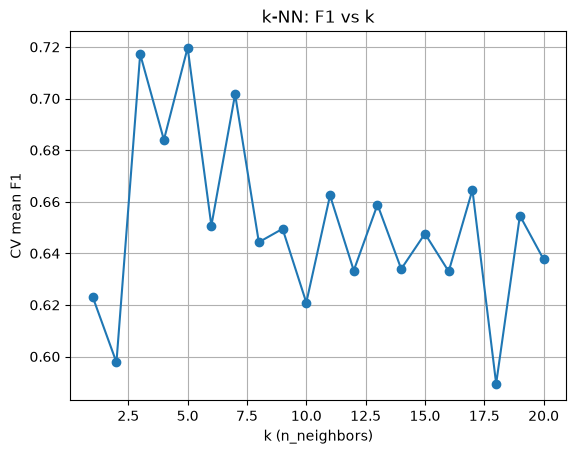

In [18]:
import numpy as np

k_range = range(1, 21)
k_f1 = []
for k in k_range:
    pipe = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=k))
    k_f1.append(cross_val_score(pipe, X_train, y_train, cv=cv, scoring='f1').mean())

best_k = list(k_range)[int(np.argmax(k_f1))]
print(f"Best k = {best_k}  (CV mean F1 = {max(k_f1):.3f})")

plt.plot(list(k_range), k_f1, marker='o')
plt.xlabel('k (n_neighbors)'); plt.ylabel('CV mean F1')
plt.title('k-NN: F1 vs k'); plt.grid(True); plt.show()


Test out different numbers of neighbors for k-NN model. The best performing one is 5.

In [19]:
from sklearn.model_selection import GridSearchCV

pipe = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
param_grid = {
    'logisticregression__C': [0.01, 0.1, 1, 10, 100],
    'logisticregression__class_weight': [None, 'balanced'],
}
grid = GridSearchCV(pipe, param_grid, cv=cv, scoring='f1')
grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print(f"Best CV F1: {grid.best_score_:.3f}")


Best params: {'logisticregression__C': 0.1, 'logisticregression__class_weight': None}
Best CV F1: 0.766


In [20]:
best_knn    = make_pipeline(StandardScaler(),
                            KNeighborsClassifier(n_neighbors=best_k)).fit(X_train, y_train)
best_logreg = grid.best_estimator_   # already fitted by GridSearchCV

for name, model in [("Improved Logistic Regression", best_logreg),
                    (f"Improved k-NN (k={best_k})", best_knn)]:
    y_pred = model.predict(X_test)   # pipeline scales X_test internally
    print(f"\n===== {name} =====")
    print("Accuracy:", round(accuracy_score(y_test, y_pred), 3))
    print("Precision:", round(precision_score(y_test, y_pred), 3))
    print("Recall:", round(recall_score(y_test, y_pred), 3))
    print("F1 score:", round(f1_score(y_test, y_pred), 3))
    print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))



===== Improved Logistic Regression =====
Accuracy: 0.977
Precision: 1.0
Recall: 0.812
F1 score: 0.897
Confusion matrix:
 [[114   0]
 [  3  13]]

===== Improved k-NN (k=5) =====
Accuracy: 0.954
Precision: 0.917
Recall: 0.688
F1 score: 0.786
Confusion matrix:
 [[113   1]
 [  5  11]]


F1 drops from the baseline, which is more realistic. This means the tuned models have better generalization, avoiding overfitting.